In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [11]:
dataset = pd.read_csv("Maternal Health Risk Data Set.csv")

## Shapes, Types and First Dataset Inspection

In [12]:
shape = dataset.shape
head = dataset.head()
info = dataset.info()

print(shape)
print(head)
print(info)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          1014 non-null   int64  
 1   SystolicBP   1014 non-null   int64  
 2   DiastolicBP  1014 non-null   int64  
 3   BS           1014 non-null   float64
 4   BodyTemp     1014 non-null   float64
 5   HeartRate    1014 non-null   int64  
 6   RiskLevel    1014 non-null   object 
dtypes: float64(2), int64(4), object(1)
memory usage: 55.6+ KB
(1014, 7)
   Age  SystolicBP  DiastolicBP    BS  BodyTemp  HeartRate  RiskLevel
0   25         130           80  15.0      98.0         86  high risk
1   35         140           90  13.0      98.0         70  high risk
2   29          90           70   8.0     100.0         80  high risk
3   30         140           85   7.0      98.0         70  high risk
4   35         120           60   6.1      98.0         76   low risk
None


In [13]:
print(dataset.isnull().sum()) # prints total number of  missing values for each attribute

duplicate_count = dataset.duplicated().sum() # prints total number of dublicated rows
duplicate_percentage = (duplicate_count / len(dataset)) * 100

print("Duplicates: ", duplicate_count)
print(f"Percentage: {duplicate_percentage:.2f}%")

Age            0
SystolicBP     0
DiastolicBP    0
BS             0
BodyTemp       0
HeartRate      0
RiskLevel      0
dtype: int64
Duplicates:  562
Percentage: 55.42%


In [14]:
duplicates = dataset[dataset.duplicated()]
duplicates

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
67,19,120,80,7.0,98.0,70,mid risk
72,19,120,80,7.0,98.0,70,mid risk
97,19,120,80,7.0,98.0,70,mid risk
106,50,140,90,15.0,98.0,90,high risk
107,25,140,100,6.8,98.0,80,high risk
...,...,...,...,...,...,...,...
1009,22,120,60,15.0,98.0,80,high risk
1010,55,120,90,18.0,98.0,60,high risk
1011,35,85,60,19.0,98.0,86,high risk
1012,43,120,90,18.0,98.0,70,high risk


In [48]:
df = dataset.drop_duplicates().copy()

In [49]:
df.shape

(452, 7)

### Report on Dataset Inspection¶
- The dataset has 1014 rows with 7 columns. 
- No missing values were detected. 
- The independent variables are all numeric. 
- 562 duplicated rows were detected which is 55% of the entire dataset. The duplicate records were removed to reduce redundancy and prevent repeated observations from biasing the analysis. The initial dataset still remains and is stored in the varable "dataset". 
- The shape of the current dataset I will be working with is 452 rows and 7 columns because the duplicated records were removed.

## Univariate Analysis

In [50]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(include='object').columns.tolist()

In [51]:
df[num_cols].describe()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
count,452.000000,452.000000,452.000000,452.000000,452.000000,452.000000
mean,29.194690,110.553097,75.418142,8.346173,98.692478,73.949115
std,13.767379,17.872282,13.754578,2.829209,1.410897,8.156973
min,10.000000,70.000000,49.000000,6.000000,98.000000,7.000000
25%,19.000000,90.000000,65.000000,6.900000,98.000000,70.000000
50%,25.000000,120.000000,80.000000,7.500000,98.000000,76.000000
75%,35.000000,120.000000,86.000000,7.900000,98.000000,80.000000
max,70.000000,160.000000,100.000000,19.000000,103.000000,90.000000


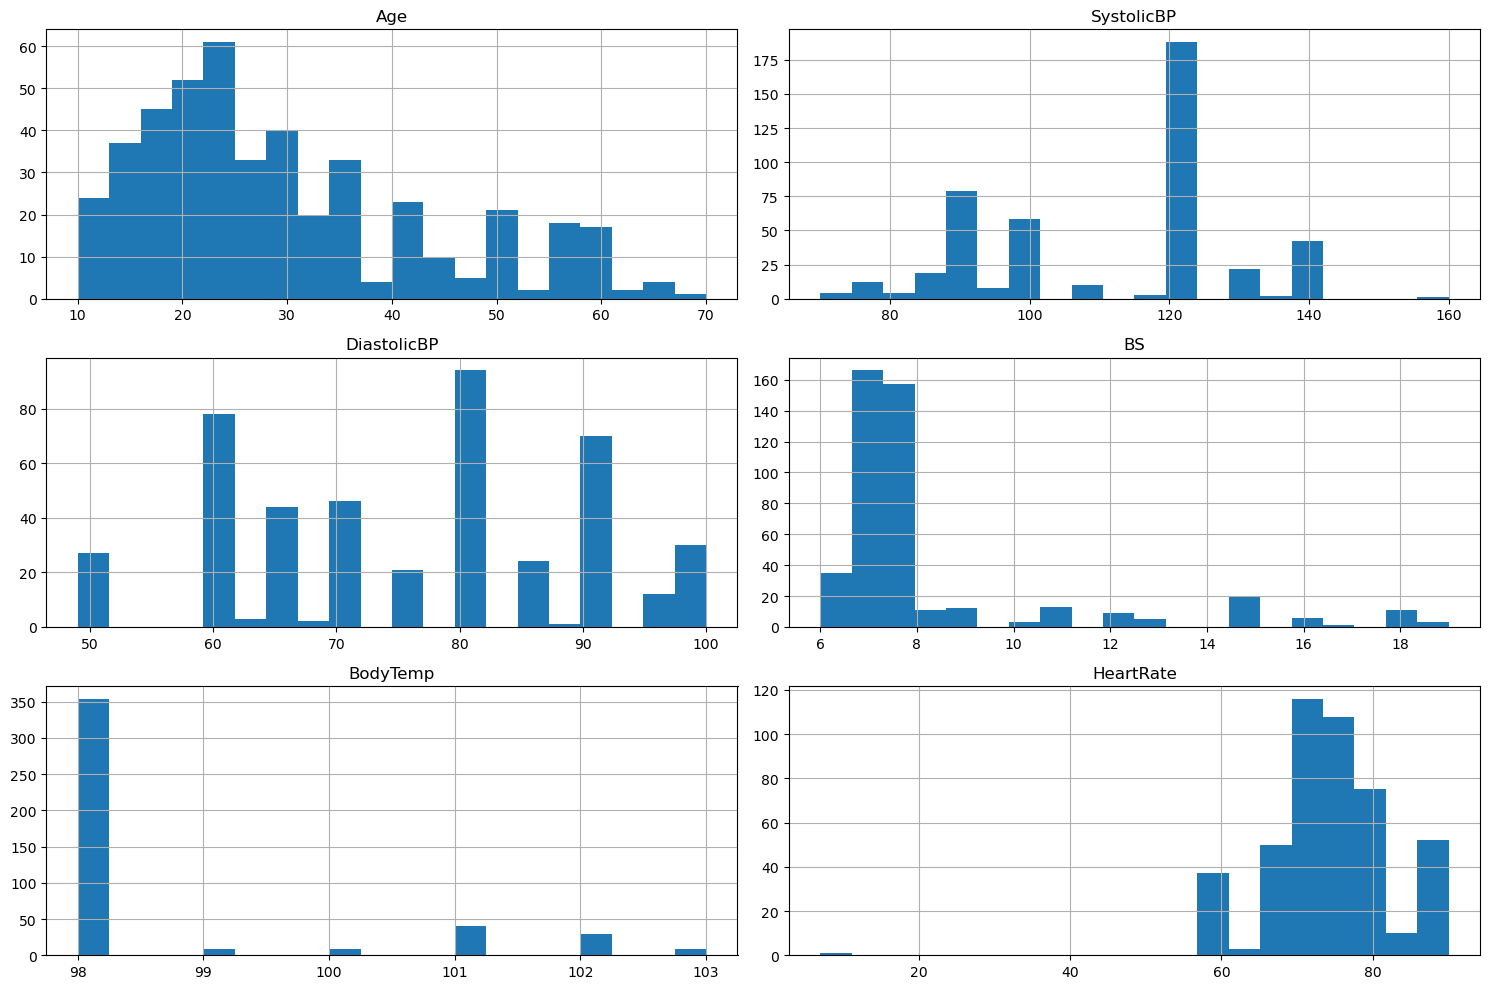

In [52]:
# Ploting to check if columns are skewed

df[num_cols].hist(
    figsize=(15,10),
    bins=20
)

plt.tight_layout()
plt.savefig('Univariate analysis.png', dpi=130)
plt.show()

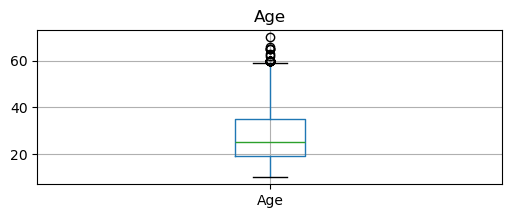

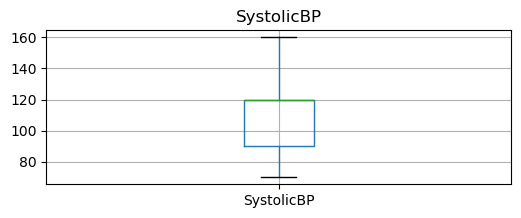

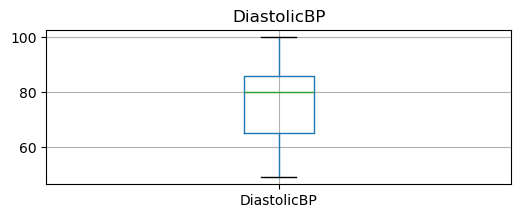

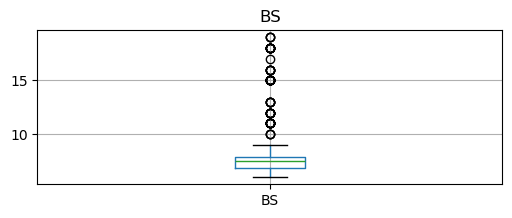

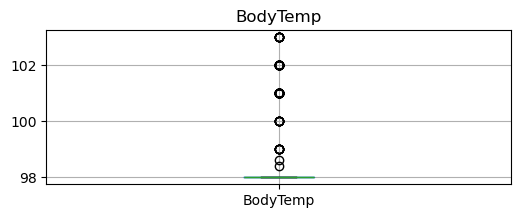

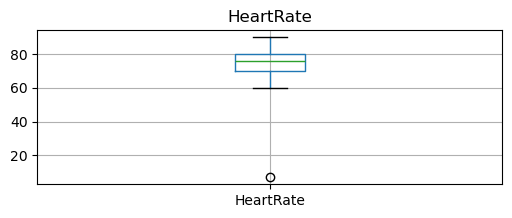

In [53]:
for col in num_cols:
    plt.figure(figsize=(6,2))
    df.boxplot(column=col)
    plt.title(col)
    plt.show()

In [54]:
df[num_cols].skew().sort_values()

HeartRate     -1.155222
SystolicBP    -0.171455
DiastolicBP   -0.028715
Age            0.922079
BodyTemp       1.751794
BS             2.262874
dtype: float64

In [55]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((df[col] < lower) | (df[col] > upper)).sum()

    print(f"{col}: {outliers} outliers")
    print(f"[{lower}, {upper}]")
    print()

Age: 23 outliers
[-5.0, 59.0]

SystolicBP: 0 outliers
[45.0, 165.0]

DiastolicBP: 0 outliers
[33.5, 117.5]

BS: 71 outliers
[5.4, 9.4]

BodyTemp: 98 outliers
[98.0, 98.0]

HeartRate: 1 outliers
[55.0, 95.0]



RiskLevel
low risk     234
high risk    112
mid risk     106
Name: count, dtype: int64 RiskLevel
low risk     51.769912
high risk    24.778761
mid risk     23.451327
Name: count, dtype: float64


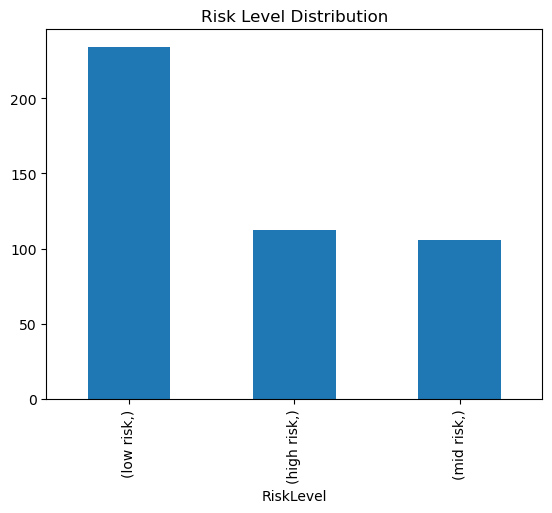

In [56]:
# print(df[cat_cols].value_counts())
unique_sum = df[cat_cols].value_counts()
unique_percentage = ((df[cat_cols].value_counts()) / len(df))*100
print(f"{unique_sum} {unique_percentage}")

df[cat_cols].value_counts().plot(kind='bar')
plt.title('Risk Level Distribution')
plt.show()

### Report on Univariate Analysis
#### Independent Features
Based on the skew values; 
- HeartRate is highly skewed to the left,
- SystolicBP is moderately symmetric,
- DiastolicBP is moderately symmetric,
- Age is moderately skewed to the right,
- BodyTemp is highly skewed to the right
- BS is highly skewed to the right.
#### Target Variable
- There are 3 levels, i.e. low risk, high risk, mid risk.
- The low risk affects 51.8% of the dataset, high risk affects 24.8% and mid risk affects 23.5% of the dataset. This is okay because there is no risk level that affects an insanly large amount of the dataset while another affects an insanely small amount of the dataset.



## Bivariate/ Multivariate Analysis

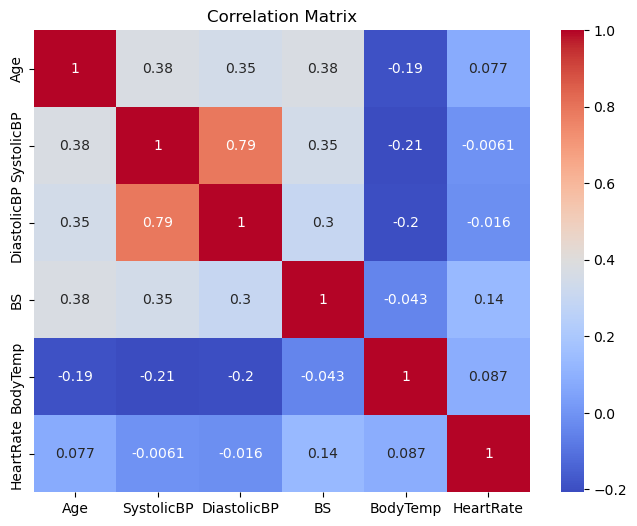

In [57]:
corr = df[['Age','SystolicBP','DiastolicBP','BS','BodyTemp','HeartRate']].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.savefig('inter-feature (correlation) relationship.png', dpi=130)
plt.show()

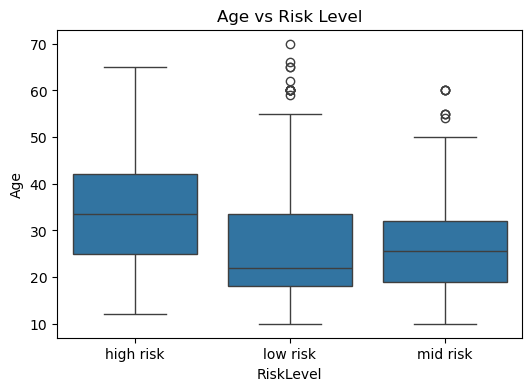

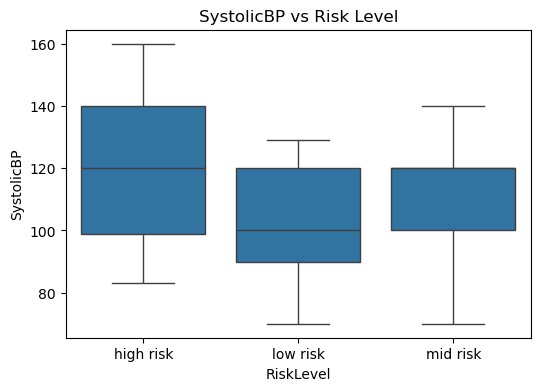

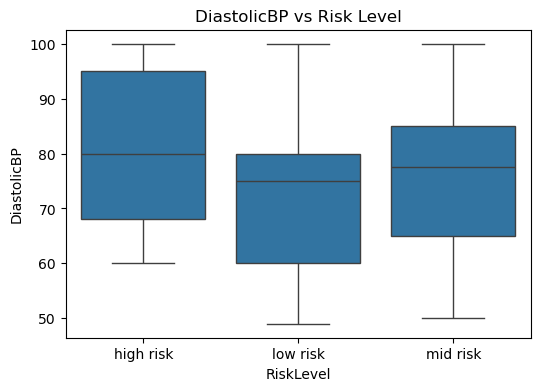

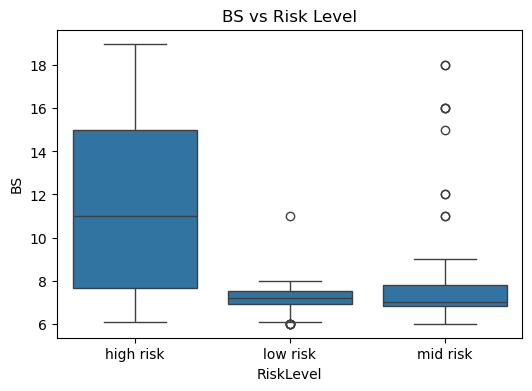

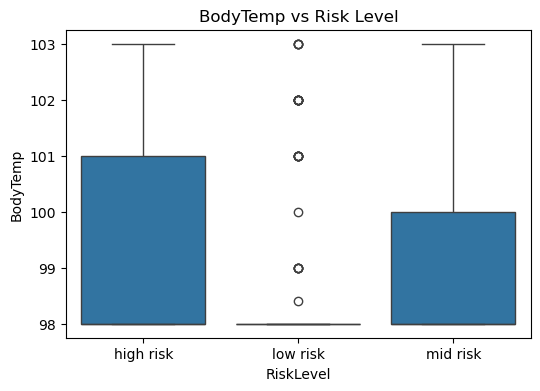

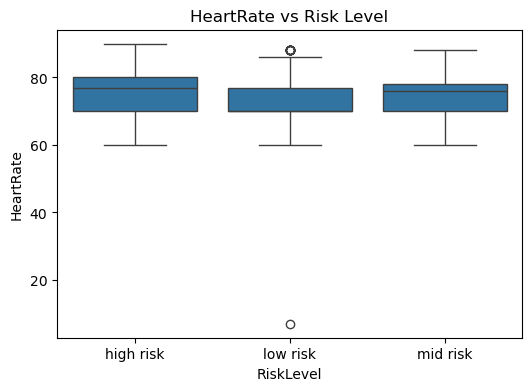

In [58]:
import seaborn as sns

for col in ['Age','SystolicBP','DiastolicBP','BS','BodyTemp','HeartRate']:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='RiskLevel', y=col, data=df)
    plt.title(f'{col} vs Risk Level')
    plt.savefig('feature vs target ralationship.png', dpi=130)
    plt.show()

### Report on Bivariate/ Multivariate Analysis
#### Relationship Between Independent Features
- The only features having a very positive relationship with each other are the SystolicBP and DiastolicBP i.e. mothers with high SystolicBP tend to have a high DiastolicBP.
- Age has a slightly positive relationship with SystolicBP, DiastolicBP and BS, i.e. older mothers tend to have a slighly high blood pressures and blood sugar levels.
- BS has a slightly possitive ralationship with SystolicBP, i.e. mothers with slightly high blood sugar level tend to have a slightly high systolicBP.
- Both body temperature and heart rate have a negative ralationship with the the other features and themselves.
#### Relationship Between Features and Target
Bivariate analysis revealed that blood sugar (BS) exhibited the strongest relationship with maternal risk level. High-risk mothers generally had substantially higher blood sugar measurements than low-risk and mid-risk mothers. Systolic and diastolic blood pressure also showed positive associations with maternal risk. Maternal age demonstrated a moderate relationship with risk level, as older mothers tended to belong to higher-risk categories. Conversely, body temperature and heart rate showed substantial overlap across risk groups, suggesting limited discriminatory power for risk classification.

## Feature Engineering
After research, features that affect the risk level of a pregnant woman are;
- Pulse pressure: It is the difference between the systolicBP and diastolicBP. But this is also not a important feature.
- Mean Arterial Pressure: It is combining both systolic and diastolic BPs to one. This will cause redundance becase it will affect the risk level the same way as both diastolic and systolic BPs so it is not neccessary to be included

## Data Encoding

In [59]:
# This steps convert the target variable, i.e. the risk level from categorical data to numerical data.
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['RiskLevel'] = le.fit_transform(df['RiskLevel'])

In [60]:
print(df.head())

   Age  SystolicBP  DiastolicBP    BS  BodyTemp  HeartRate  RiskLevel
0   25         130           80  15.0      98.0         86          0
1   35         140           90  13.0      98.0         70          0
2   29          90           70   8.0     100.0         80          0
3   30         140           85   7.0      98.0         70          0
4   35         120           60   6.1      98.0         76          1


## Train_Test_Split

In [61]:
from sklearn.model_selection import train_test_split

X = df.drop('RiskLevel', axis=1)
y = df['RiskLevel']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [62]:
print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)

X_train.to_csv('X_train.csv', index=False)
X_test.to_csv('X_test.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
y_test.to_csv('y_test.csv', index=False)

Train shape: (361, 6)
Test shape : (91, 6)


## Training


In [64]:
# Using Random Forest. Because it is not a binary classification baseline

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [65]:
y_pred = rf.predict(X_test)

In [66]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.5714285714285714


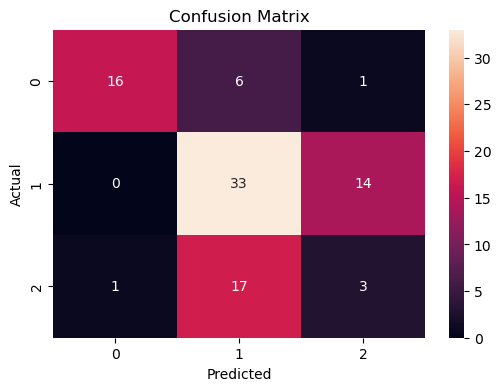

In [67]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [68]:
# Folding

from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    rf,
    X,
    y,
    cv=10,
    scoring='accuracy'
)

print("Fold Accuracies:")
print(scores)

print("\nMean Accuracy:", scores.mean())
print("Std Dev:", scores.std())

Fold Accuracies:
[0.76086957 0.82608696 0.57777778 0.68888889 0.6        0.71111111
 0.53333333 0.44444444 0.53333333 0.68888889]

Mean Accuracy: 0.6364734299516909
Std Dev: 0.1119908983175931


In [69]:
# Using logistic regression
# Scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [70]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [71]:
y_pred = lr.predict(X_test_scaled)

In [72]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.6703296703296703
              precision    recall  f1-score   support

           0       0.81      0.57      0.67        23
           1       0.64      1.00      0.78        47
           2       1.00      0.05      0.09        21

    accuracy                           0.67        91
   macro avg       0.82      0.54      0.51        91
weighted avg       0.76      0.67      0.59        91



In [73]:
# folding

from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=cv,
    scoring='accuracy'
)

print("Fold Accuracies:")
print(scores)

print("\nMean Accuracy:", scores.mean())
print("Standard Deviation:", scores.std())

Fold Accuracies:
[0.7173913  0.67391304 0.62222222 0.64444444 0.68888889 0.64444444
 0.62222222 0.62222222 0.75555556 0.62222222]

Mean Accuracy: 0.6613526570048309
Standard Deviation: 0.044302440649701916


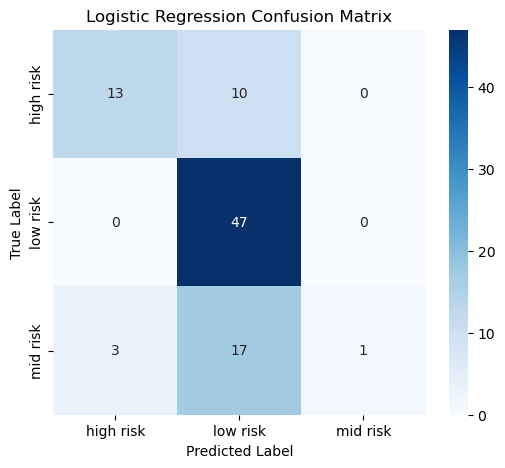

In [74]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

# Optimized Version

In [91]:
dataset.head()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk


In [154]:
df1 = dataset.copy()
df1.head()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk


In [155]:
# 2. Clean impossible clinical outliers
df1 = df1[df1['HeartRate'] >= 40]

In [156]:
# 3. Apply custom Ordinal Encoding directly to the string labels
risk_mapping = {'low risk': 0, 'mid risk': 1, 'high risk': 2}
df1['RiskLevel'] = df1['RiskLevel'].map(risk_mapping)

In [157]:
df1.head()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,2
1,35,140,90,13.0,98.0,70,2
2,29,90,70,8.0,100.0,80,2
3,30,140,85,7.0,98.0,70,2
4,35,120,60,6.1,98.0,76,0


In [158]:
# 4. Feature Engineering
df1['PulsePressure'] = df1['SystolicBP'] - df1['DiastolicBP']
df1['MAP'] = df1['DiastolicBP'] + ((df1['SystolicBP'] - df1['DiastolicBP']) / 3)
df1['HighBS'] = (df1['BS'] >= 8.0).astype(int)


In [159]:
df1.head()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel,PulsePressure,MAP,HighBS
0,25,130,80,15.0,98.0,86,2,50,96.666667,1
1,35,140,90,13.0,98.0,70,2,50,106.666667,1
2,29,90,70,8.0,100.0,80,2,20,76.666667,1
3,30,140,85,7.0,98.0,70,2,55,103.333333,0
4,35,120,60,6.1,98.0,76,0,60,80.000000,0


In [160]:
df1.head()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel,PulsePressure,MAP,HighBS
0,25,130,80,15.0,98.0,86,2,50,96.666667,1
1,35,140,90,13.0,98.0,70,2,50,106.666667,1
2,29,90,70,8.0,100.0,80,2,20,76.666667,1
3,30,140,85,7.0,98.0,70,2,55,103.333333,0
4,35,120,60,6.1,98.0,76,0,60,80.000000,0


In [161]:
# 5. Split data (This will now work flawlessly without NaN errors!)
X = df1.drop('RiskLevel', axis=1)
y = df1['RiskLevel']

In [162]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [163]:
# Add class_weight='balanced' to both models
model = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
model1 = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')

In [164]:
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [165]:
y_pred = model.predict(X_test)

In [166]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8423645320197044


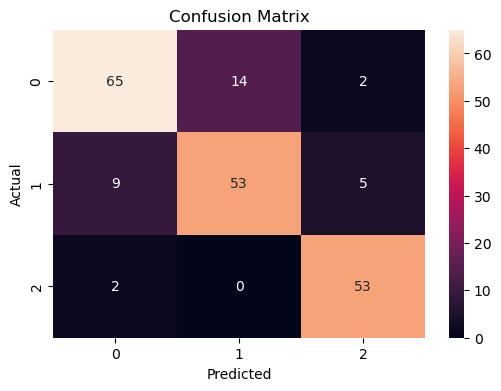

In [167]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [168]:
import joblib
joblib.dump(model, 'rf_model.joblib')

['rf_model.joblib']

In [105]:
# 6. Scale data (Critical for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [106]:
model1.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [108]:
y_pred = model1.predict(X_test_scaled)

In [110]:
accuracy1 = accuracy_score(y_test, y_pred)
print(accuracy1)

0.6798029556650246


In [109]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.6798029556650246
              precision    recall  f1-score   support

           0       0.70      0.69      0.70        81
           1       0.56      0.49      0.52        67
           2       0.77      0.89      0.82        55

    accuracy                           0.68       203
   macro avg       0.67      0.69      0.68       203
weighted avg       0.67      0.68      0.67       203

